<a href="https://colab.research.google.com/github/SteAmarante/python-data-science/blob/main/aula_08/projeto_integrador_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Projeto Integrador na base OULAD (Open University Learning Analytics Dataset)

**Tema:** Prevendo desempenho estudantil a partir de dados dados sobre cursos, alunos e suas interações com o Ambiente Virtual de Aprendizagem;


**Objetivo:** Construir um mini-pipeline de dados e um modelo preditivo para classificar alunos como **“aprovado/reprovado”**.

Brief do projeto


- Coletar/Carregar uma base pública de educação (https://analyse.kmi.open.ac.uk/open-dataset).

- Bronze: armazenar os dados crus (sem alterações).

- Silver: limpar/transformar (tipos, nulos, codificações, features).

- EDA: explorar com Pandas + Seaborn (distribuições, correlações,comparativos).

- ML: modelar com RandomForest para prever sucesso (Pass/Distinction) vs não-sucesso (Fail/Withdraw).

- NumPy (Tensor): representar aluno × semana × cliques e extrair estatísticas.

- Gold: criar bases analíticas (agregações e features finais).

- Interação + Funções: perguntar ao usuário filtros/limiares e aplicar via funções.

- Montar tudo no google colab de forma documentada !

In [ ]:
!pip install scikit-learn

In [ ]:
!pip install SQLAlchemy

In [ ]:
# Importar pacotes essenciais
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
import joblib


sns.set_theme(style="whitegrid")
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

##Bronze

In [ ]:
# Conexão (cria o arquivo se não existir)
engine = create_engine("sqlite:///lakehouse.db")

###Tabela studentVle

In [ ]:
##Coletar/Carregar uma base pública de educação - Camada Bronze
df_cliques = pd.read_csv("/content/studentVle.csv")
df_cliques.to_sql("studentVle_bronze", engine, if_exists="replace", index=False)
df_cliques

,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400.0,546652.0,-10.0,4.0
1,AAA,2013J,28400.0,546652.0,-10.0,1.0
2,AAA,2013J,28400.0,546652.0,-10.0,1.0
3,AAA,2013J,28400.0,546614.0,-10.0,11.0
4,AAA,2013J,28400.0,546714.0,-10.0,1.0
...,...,...,...,...,...,...
3818280,DDD,2013J,2068627.0,674435.0,21.0,1.0
3818281,DDD,2013J,2068627.0,674105.0,21.0,1.0
3818282,DDD,2013J,2068627.0,674129.0,21.0,4.0
3818283,DDD,2013J,2068627.0,674108.0,21.0,1.0


###Tabela vle

In [ ]:
##Coletar/Carregar uma base pública de educação - Camada Bronze
df_semana = pd.read_csv("/content/vle.csv")
df_semana.to_sql("vle_bronze", engine, if_exists="replace", index=False)
df_semana

,id_site,code_module,code_presentation,activity_type,week_from,week_to
0,546943,AAA,2013J,resource,NaN,NaN
1,546712,AAA,2013J,oucontent,NaN,NaN
2,546998,AAA,2013J,resource,NaN,NaN
3,546888,AAA,2013J,url,NaN,NaN
4,547035,AAA,2013J,resource,NaN,NaN
...,...,...,...,...,...,...
6359,897063,GGG,2014J,resource,NaN,NaN
6360,897109,GGG,2014J,resource,NaN,NaN
6361,896965,GGG,2014J,oucontent,NaN,NaN
6362,897060,GGG,2014J,resource,NaN,NaN


###Tabela studentInfo

In [ ]:
##Coletar/Carregar uma base pública de educação - Camada Bronze
df_info = pd.read_csv("/content/studentInfo.csv")
df_info.to_sql("studentInfo_bronze", engine, if_exists="replace", index=False)
df_info

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass
...,...,...,...,...,...,...,...,...,...,...,...,...
32588,GGG,2014J,2640965,F,Wales,Lower Than A Level,10-20,0-35,0,30,N,Fail
32589,GGG,2014J,2645731,F,East Anglian Region,Lower Than A Level,40-50%,35-55,0,30,N,Distinction
32590,GGG,2014J,2648187,F,South Region,A Level or Equivalent,20-30%,0-35,0,30,Y,Pass
32591,GGG,2014J,2679821,F,South East Region,Lower Than A Level,90-100%,35-55,0,30,N,Withdrawn


###Tabela studentAssessment

In [ ]:
##Coletar/Carregar uma base pública de educação - Camada Bronze
df_nota = pd.read_csv("/content/studentAssessment.csv")
df_nota.to_sql("studentAssessment_bronze", engine, if_exists="replace", index=False)
df_nota

,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78.0
1,1752,28400,22,0,70.0
2,1752,31604,17,0,72.0
3,1752,32885,26,0,69.0
4,1752,38053,19,0,79.0
...,...,...,...,...,...
173907,37443,527538,227,0,60.0
173908,37443,534672,229,0,100.0
173909,37443,546286,215,0,80.0
173910,37443,546724,230,0,100.0


##Silver

###Tabela studentInfo

In [ ]:
#Verificar se tem nulos na tabela studentInfo
df_info.isnull().sum()

,0
code_module,0
code_presentation,0
id_student,0
gender,0
region,0
highest_education,0
imd_band,1111
age_band,0
num_of_prev_attempts,0
studied_credits,0


In [ ]:
# Silver: limpar/transformar (tipos, nulos, codificações, features). na tabela studentInfo
df_info = df_info.dropna()
df_info.to_sql("studentInfo_silver", engine, if_exists="replace", index=False)

31482

In [ ]:
#Verificar se os  nulos na tabela studentInfo foram retirados
df_info.isnull().sum()

,0
code_module,0
code_presentation,0
id_student,0
gender,0
region,0
highest_education,0
imd_band,0
age_band,0
num_of_prev_attempts,0
studied_credits,0


In [ ]:
df_info.isnull().sum().sum()

np.int64(0)

###Tabela studentVle

In [ ]:
#Verificar se tem nulos na tabela studentInfo
df_semana.isnull().sum()

,0
id_site,0
code_module,0
code_presentation,0
activity_type,0
week_from,5243
week_to,5243


###Tabela vle

In [ ]:
#Verificar se tem nulos na tabela studentInfo
df_cliques.isnull().sum()

,0
code_module,0
code_presentation,1
id_student,1
id_site,1
date,1
sum_click,1


###Tabela studentAssessment

In [ ]:
df_nota.isnull().sum()

,0
id_assessment,0
id_student,0
date_submitted,0
is_banked,0
score,173


In [ ]:
df_nota = df_nota.dropna()
df_nota.to_sql("studentAssessment_silver", engine, if_exists="replace", index=False)

173739

In [ ]:
df_nota.isnull().sum()

,0
id_assessment,0
id_student,0
date_submitted,0
is_banked,0
score,0


In [ ]:
df_nota.isnull().sum().sum()

np.int64(0)

##Geração de novos dados:  Silver -> Gold

###EDA: explorar com Pandas + Seaborn (distribuições (histograma), correlações(hitmap), comparativos(Colunas)).

####Tabela studentInfo

In [ ]:
# Análise inicial
print("=== df_info (Informações dos Estudantes) ===")
print(f"Shape: {df_info.shape}")
print("\nColunas:")
print(df_info.columns.tolist())
print("\nTipos de dados:")
print(df_info.dtypes)
print("\nValores nulos:")
print(df_info.isnull().sum())
print("\nPrimeiras linhas:")
df_info.head()

=== df_info (Informações dos Estudantes) ===
Shape: (31482, 12)

Colunas:
['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result']

Tipos de dados:
code_module             object
code_presentation       object
id_student               int64
gender                  object
region                  object
highest_education       object
imd_band                object
age_band                object
num_of_prev_attempts     int64
studied_credits          int64
disability              object
final_result            object
dtype: object

Valores nulos:
code_module             0
code_presentation       0
id_student              0
gender                  0
region                  0
highest_education       0
imd_band                0
age_band                0
num_of_prev_attempts    0
studied_credits         0
disability              0
final_result            0
dtype:

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


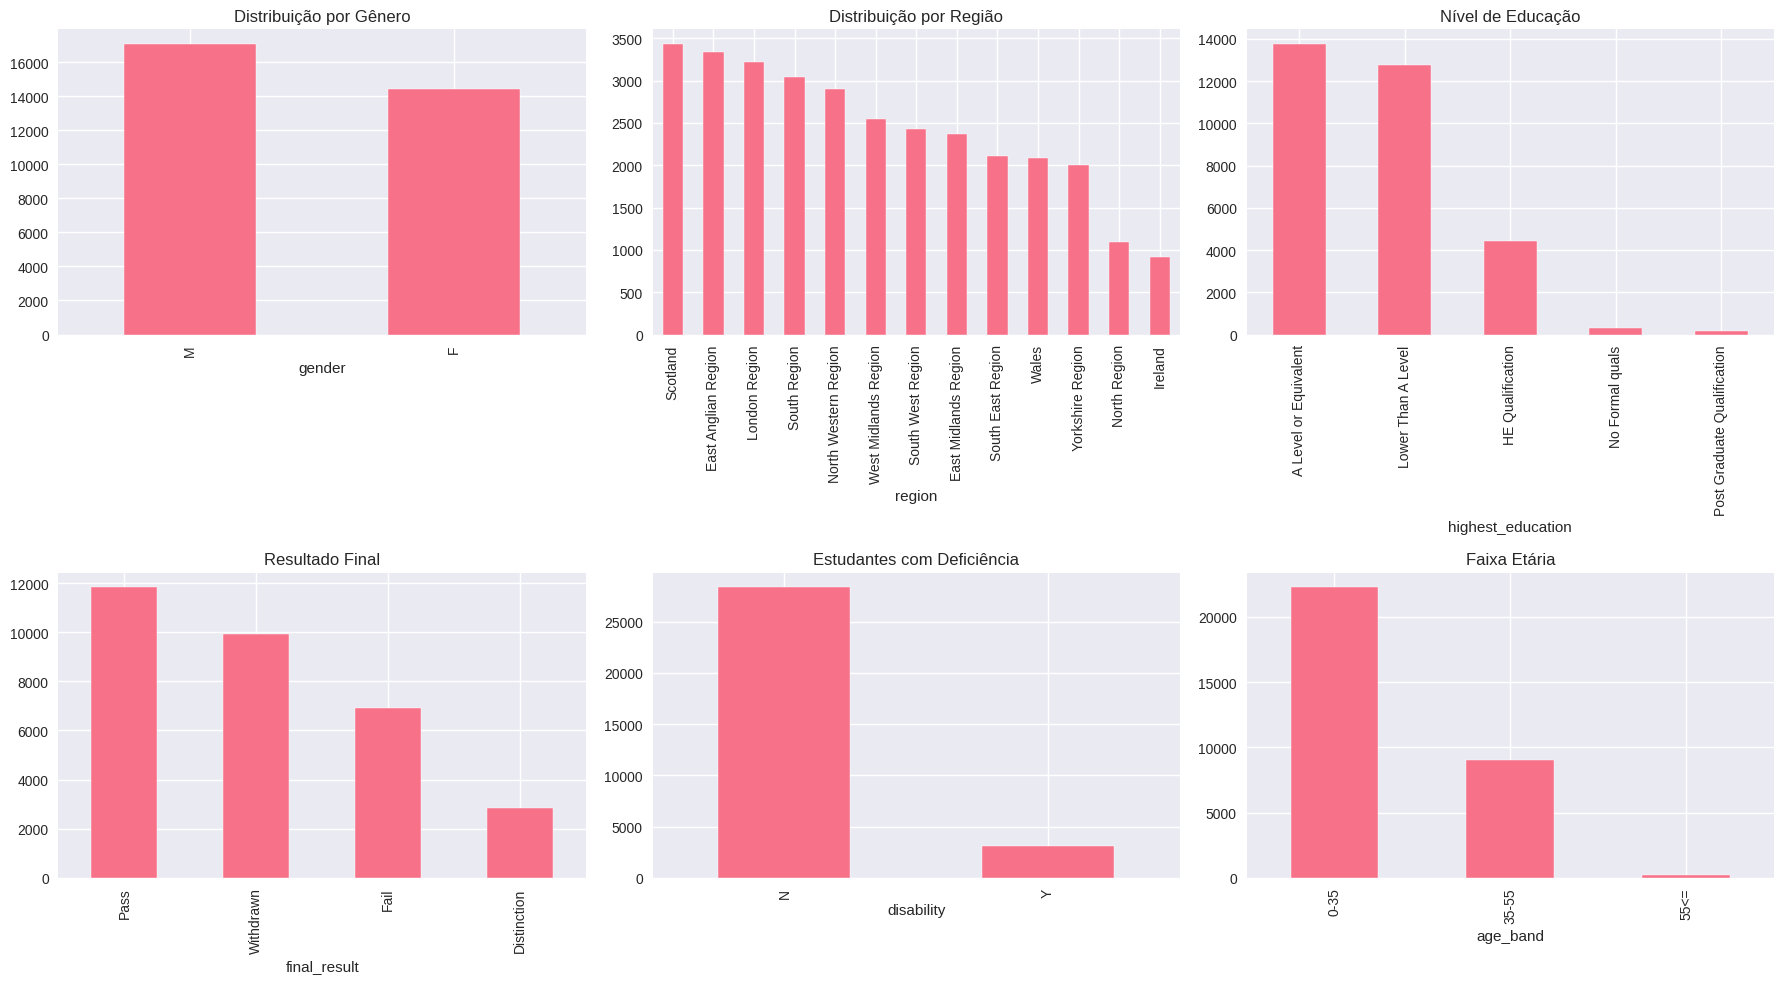

In [ ]:
# Distribuição das variáveis categóricas principais
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Gênero
df_info['gender'].value_counts().plot(kind='bar', ax=axes[0,0], title='Distribuição por Gênero')

# Região
df_info['region'].value_counts().plot(kind='bar', ax=axes[0,1], title='Distribuição por Região')

# Nível de Educação
df_info['highest_education'].value_counts().plot(kind='bar', ax=axes[0,2], title='Nível de Educação')

# Status Final
df_info['final_result'].value_counts().plot(kind='bar', ax=axes[1,0], title='Resultado Final')

# Deficiência
df_info['disability'].value_counts().plot(kind='bar', ax=axes[1,1], title='Estudantes com Deficiência')

# Idade
df_info['age_band'].value_counts().plot(kind='bar', ax=axes[1,2], title='Faixa Etária')

plt.tight_layout()
plt.show()

Colunas no dataframe de correlação:
gender                  int64
region                  int64
highest_education       int64
imd_band                int64
age_band                int64
num_of_prev_attempts    int64
studied_credits         int64
disability              int64
final_result            int64
dtype: object


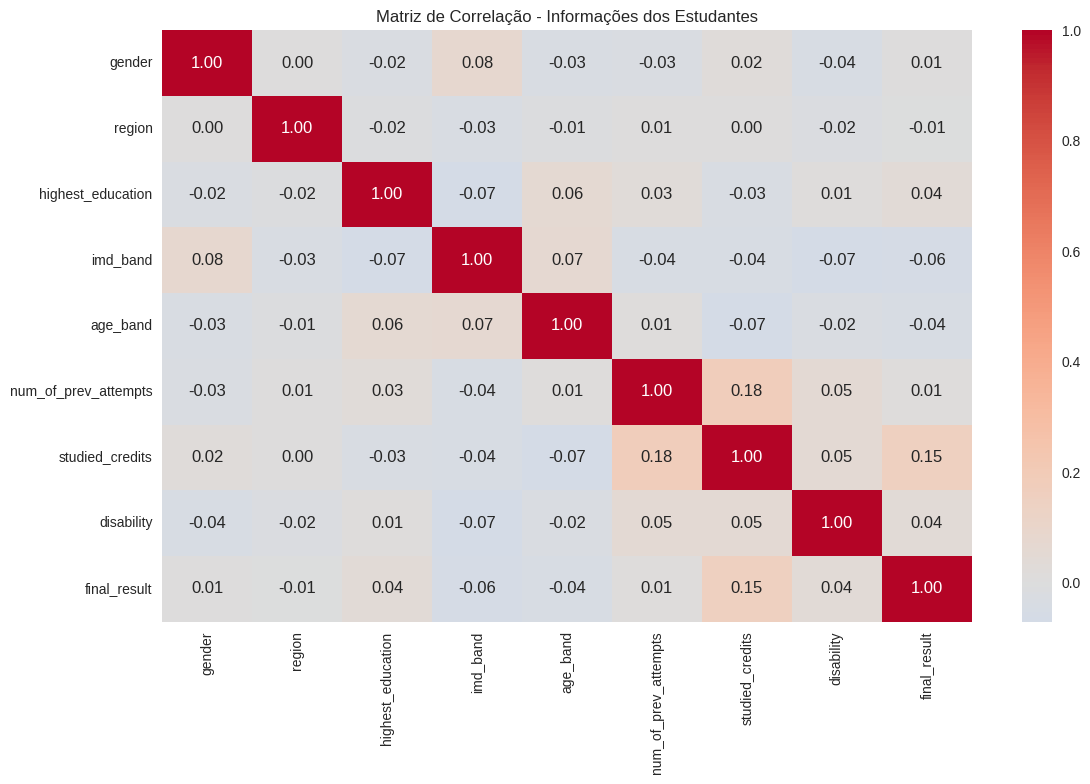


Correlações com a variável target (final_result):
final_result            1.000000
studied_credits         0.154630
highest_education       0.040735
disability              0.039937
num_of_prev_attempts    0.014806
gender                  0.007555
region                 -0.006909
age_band               -0.037400
imd_band               -0.059239
Name: final_result, dtype: float64


In [ ]:
# Análise de correlações (variáveis numéricas)
# Primeiro precisamos codificar algumas variáveis categóricas para análise de correlação
df_info_encoded = df_info.copy()

# Codificar variáveis categóricas
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

categorical_cols = ['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability', 'final_result']

# Primeiro, verificar quais colunas categóricas realmente existem no dataframe
categorical_cols = [col for col in categorical_cols if col in df_info_encoded.columns]

# Excluir colunas que não devem ser codificadas ou usadas na correlação
exclude_from_correlation = ['id_student', 'code_module', 'code_presentation']

# Filtrar apenas colunas relevantes para análise de correlação
cols_para_correlacao = [col for col in df_info_encoded.columns
                       if col not in exclude_from_correlation]

# Criar um dataframe apenas com as colunas que queremos analisar
df_corr = df_info_encoded[cols_para_correlacao].copy()

# Codificar apenas as variáveis categóricas que estão presentes
for col in categorical_cols:
    if col in df_corr.columns:
        df_corr[col] = le.fit_transform(df_corr[col].astype(str))

# Verificar se todas as colunas são numéricas agora
print("Colunas no dataframe de correlação:")
print(df_corr.dtypes)

# Matriz de correlação - usar apenas colunas numéricas
numeric_cols = df_corr.select_dtypes(include=[np.number]).columns.tolist()
df_corr_numeric = df_corr[numeric_cols]

plt.figure(figsize=(12, 8))
corr_matrix = df_corr_numeric.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matriz de Correlação - Informações dos Estudantes')
plt.tight_layout()
plt.show()

# Opcional: mostrar valores de correlação com o target se existir
if 'final_result' in df_corr_numeric.columns:
    print("\nCorrelações com a variável target (final_result):")
    correlacoes_target = df_corr_numeric.corr()['final_result'].sort_values(ascending=False)
    print(correlacoes_target)

####Tabela studentVle

In [ ]:
print("=== df_cliques (Interações VLE) ===")
print(f"Shape: {df_cliques.shape}")
print("\nColunas:")
print(df_cliques.columns.tolist())
print("\nValores nulos:")
print(df_cliques.isnull().sum())
df_cliques.head()

=== df_cliques (Interações VLE) ===
Shape: (3818285, 6)

Colunas:
['code_module', 'code_presentation', 'id_student', 'id_site', 'date', 'sum_click']

Valores nulos:
code_module          0
code_presentation    1
id_student           1
id_site              1
date                 1
sum_click            1
dtype: int64


,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400.0,546652.0,-10.0,4.0
1,AAA,2013J,28400.0,546652.0,-10.0,1.0
2,AAA,2013J,28400.0,546652.0,-10.0,1.0
3,AAA,2013J,28400.0,546614.0,-10.0,11.0
4,AAA,2013J,28400.0,546714.0,-10.0,1.0


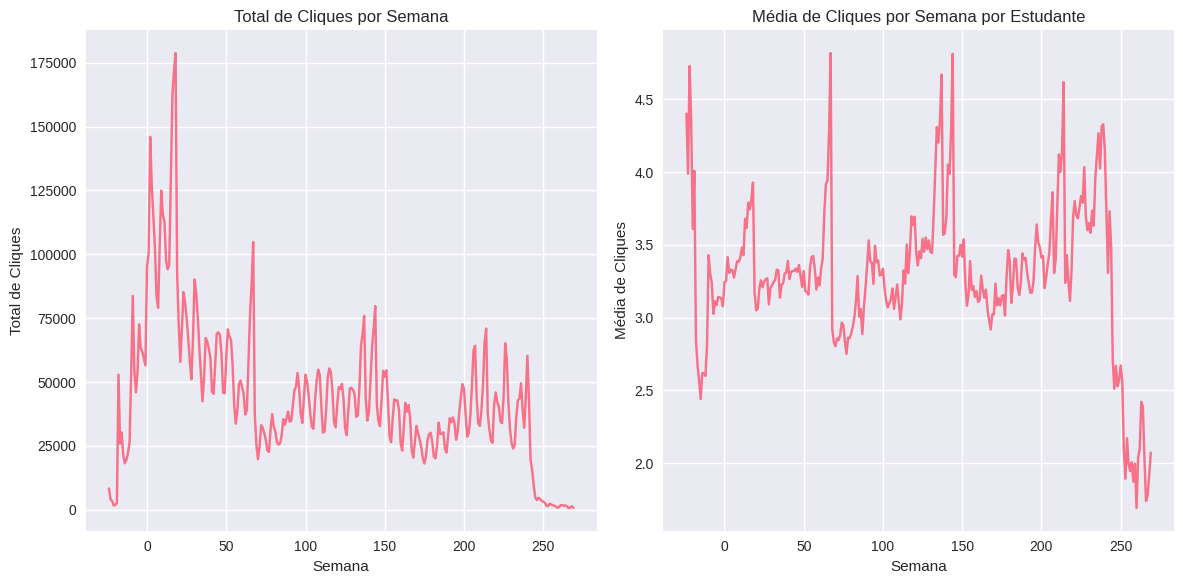

In [ ]:
# Análise temporal dos cliques
plt.figure(figsize=(12, 6))

# Cliques por semana
cliques_por_semana = df_cliques.groupby('date')['sum_click'].sum()
plt.subplot(1, 2, 1)
cliques_por_semana.plot(title='Total de Cliques por Semana')
plt.xlabel('Semana')
plt.ylabel('Total de Cliques')

# Média de cliques por semana
media_cliques_semana = df_cliques.groupby('date')['sum_click'].mean()
plt.subplot(1, 2, 2)
media_cliques_semana.plot(title='Média de Cliques por Semana por Estudante')
plt.xlabel('Semana')
plt.ylabel('Média de Cliques')

plt.tight_layout()
plt.show()

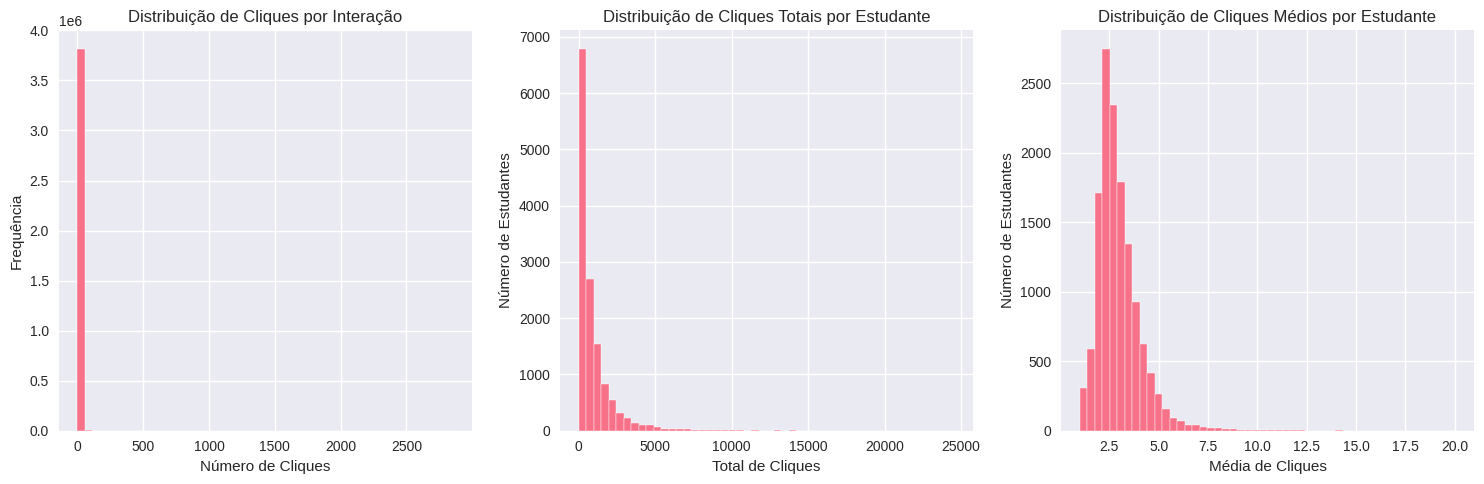

In [ ]:
# Distribuição geral de cliques
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
df_cliques['sum_click'].hist(bins=50)
plt.title('Distribuição de Cliques por Interação')
plt.xlabel('Número de Cliques')
plt.ylabel('Frequência')

plt.subplot(1, 3, 2)
# Cliques totais por estudante
cliques_por_estudante = df_cliques.groupby('id_student')['sum_click'].sum()
cliques_por_estudante.hist(bins=50)
plt.title('Distribuição de Cliques Totais por Estudante')
plt.xlabel('Total de Cliques')
plt.ylabel('Número de Estudantes')

plt.subplot(1, 3, 3)
# Cliques médios por estudante
cliques_medio_estudante = df_cliques.groupby('id_student')['sum_click'].mean()
cliques_medio_estudante.hist(bins=50)
plt.title('Distribuição de Cliques Médios por Estudante')
plt.xlabel('Média de Cliques')
plt.ylabel('Número de Estudantes')

plt.tight_layout()
plt.show()

####Tabela studentAssessment

In [ ]:
print("=== df_nota (Avaliações) ===")
print(f"Shape: {df_nota.shape}")
print("\nColunas:")
print(df_nota.columns.tolist())
print("\nValores nulos:")
print(df_nota.isnull().sum())
df_nota.head()

=== df_nota (Avaliações) ===
Shape: (173739, 5)

Colunas:
['id_assessment', 'id_student', 'date_submitted', 'is_banked', 'score']

Valores nulos:
id_assessment     0
id_student        0
date_submitted    0
is_banked         0
score             0
dtype: int64


,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78.0
1,1752,28400,22,0,70.0
2,1752,31604,17,0,72.0
3,1752,32885,26,0,69.0
4,1752,38053,19,0,79.0


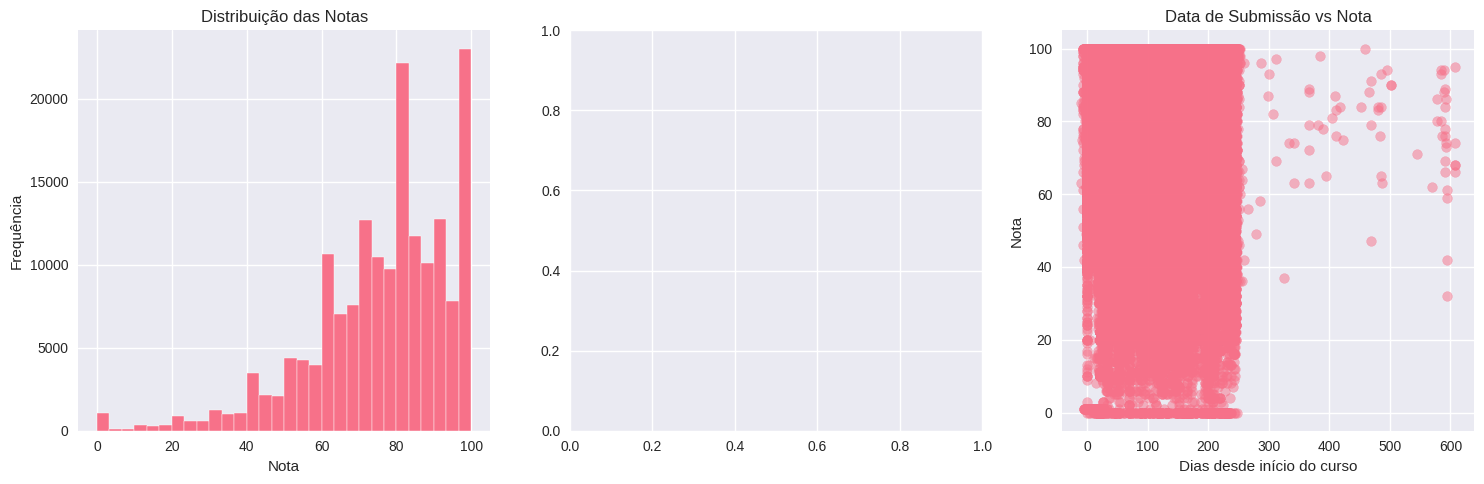

In [ ]:
# Análise das notas
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
df_nota['score'].hist(bins=30)
plt.title('Distribuição das Notas')
plt.xlabel('Nota')
plt.ylabel('Frequência')

plt.subplot(1, 3, 2)
# Notas por tipo de avaliação
if 'assessment_type' in df_nota.columns:
    sns.boxplot(data=df_nota, x='assessment_type', y='score')
    plt.title('Distribuição de Notas por Tipo de Avaliação')
    plt.xticks(rotation=45)

plt.subplot(1, 3, 3)
# Data de submissão vs nota
if 'date_submitted' in df_nota.columns:
    plt.scatter(df_nota['date_submitted'], df_nota['score'], alpha=0.5)
    plt.title('Data de Submissão vs Nota')
    plt.xlabel('Dias desde início do curso')
    plt.ylabel('Nota')

plt.tight_layout()
plt.show()

####Tabela Vle


In [ ]:
print("=== df_semana (Materiais VLE) ===")
print(f"Shape: {df_semana.shape}")
print("\nColunas:")
print(df_semana.columns.tolist())
print("\nValores nulos:")
print(df_semana.isnull().sum())
df_semana.head()

=== df_semana (Materiais VLE) ===
Shape: (6364, 6)

Colunas:
['id_site', 'code_module', 'code_presentation', 'activity_type', 'week_from', 'week_to']

Valores nulos:
id_site                 0
code_module             0
code_presentation       0
activity_type           0
week_from            5243
week_to              5243
dtype: int64


,id_site,code_module,code_presentation,activity_type,week_from,week_to
0,546943,AAA,2013J,resource,NaN,NaN
1,546712,AAA,2013J,oucontent,NaN,NaN
2,546998,AAA,2013J,resource,NaN,NaN
3,546888,AAA,2013J,url,NaN,NaN
4,547035,AAA,2013J,resource,NaN,NaN


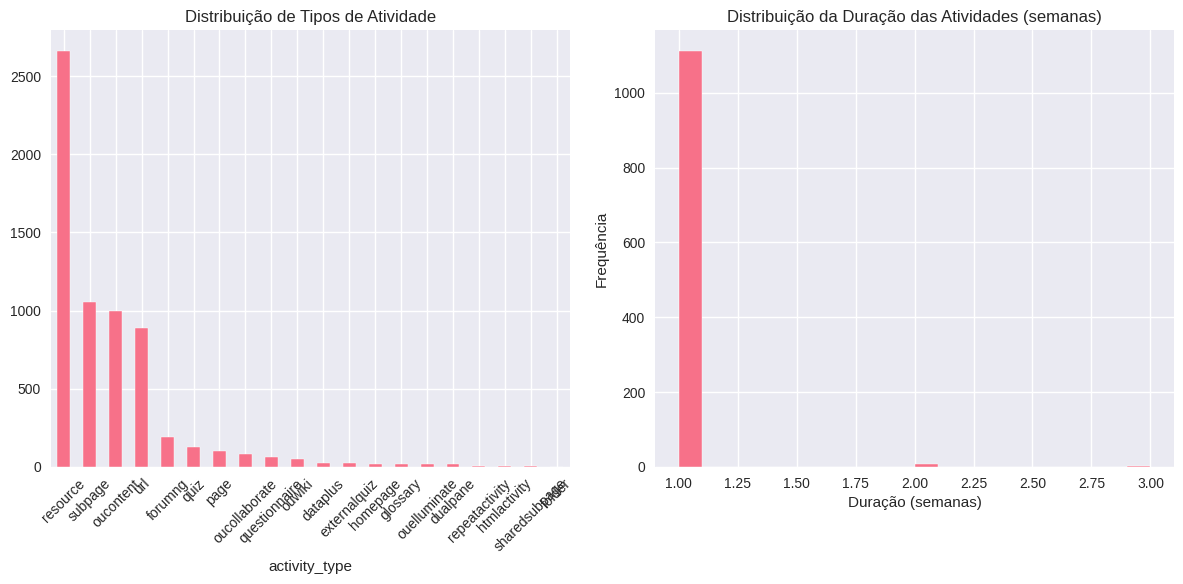

In [ ]:
# Análise dos tipos de materiais
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
if 'activity_type' in df_semana.columns:
    df_semana['activity_type'].value_counts().plot(kind='bar')
    plt.title('Distribuição de Tipos de Atividade')
    plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
if 'week_from' in df_semana.columns and 'week_to' in df_semana.columns:
    # Duração das atividades
    duracao = df_semana['week_to'] - df_semana['week_from'] + 1
    duracao.hist(bins=20)
    plt.title('Distribuição da Duração das Atividades (semanas)')
    plt.xlabel('Duração (semanas)')
    plt.ylabel('Frequência')

plt.tight_layout()
plt.show()

#### Análises Integradas (Cross-Tables)


In [ ]:
# Juntar informações para análise combinada
# Primeiro, vamos agregar cliques por estudante
cliques_agregados = df_cliques.groupby('id_student').agg({
    'sum_click': ['sum', 'mean', 'count']
}).reset_index()
cliques_agregados.columns = ['id_student', 'total_cliques', 'media_cliques', 'num_interacoes']

# Juntar com informações dos estudantes
df_merged = pd.merge(df_info, cliques_agregados, on='id_student', how='left')

# Agregar notas por estudante
if 'id_student' in df_nota.columns and 'score' in df_nota.columns:
    notas_agregadas = df_nota.groupby('id_student')['score'].agg(['mean', 'max', 'min', 'count']).reset_index()
    notas_agregadas.columns = ['id_student', 'media_nota', 'max_nota', 'min_nota', 'num_avaliacoes']
    df_merged = pd.merge(df_merged, notas_agregadas, on='id_student', how='left')

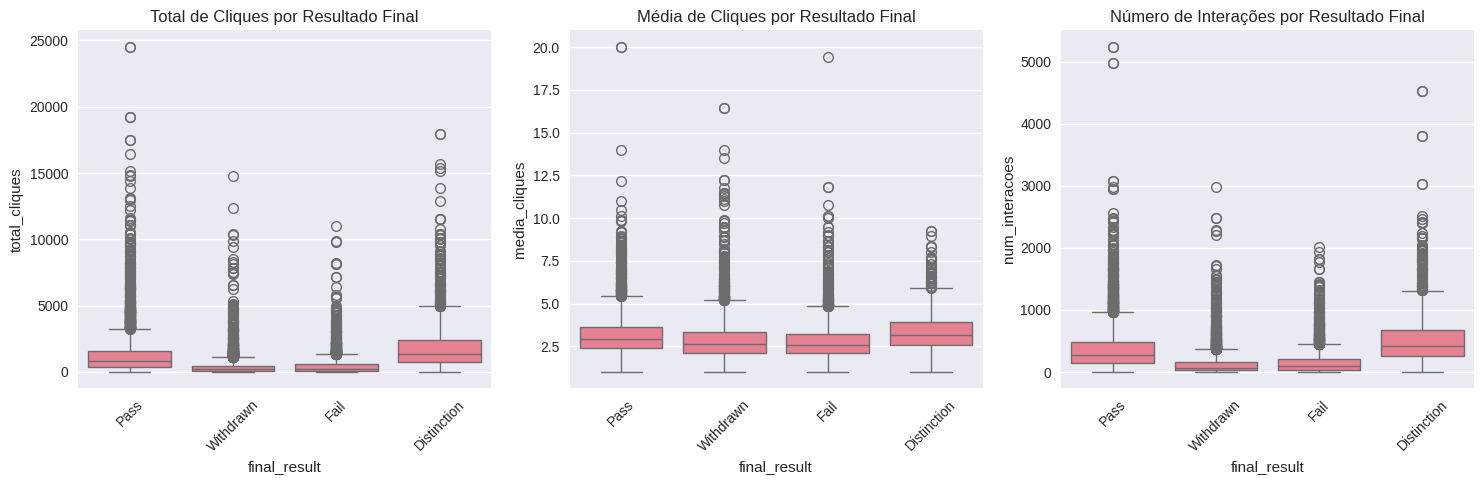

In [ ]:
# Análise: Cliques vs Resultado Final
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(data=df_merged, x='final_result', y='total_cliques')
plt.title('Total de Cliques por Resultado Final')
plt.xticks(rotation=45)

plt.subplot(1, 3, 2)
sns.boxplot(data=df_merged, x='final_result', y='media_cliques')
plt.title('Média de Cliques por Resultado Final')
plt.xticks(rotation=45)

plt.subplot(1, 3, 3)
sns.boxplot(data=df_merged, x='final_result', y='num_interacoes')
plt.title('Número de Interações por Resultado Final')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

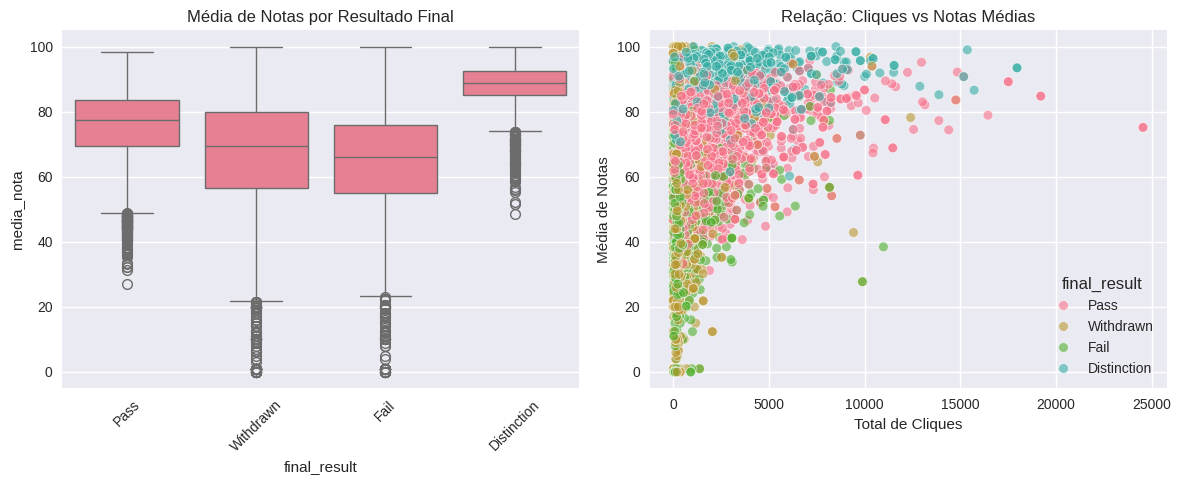

In [ ]:
# Análise: Notas vs Resultado Final (se disponível)
if 'media_nota' in df_merged.columns:
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.boxplot(data=df_merged, x='final_result', y='media_nota')
    plt.title('Média de Notas por Resultado Final')
    plt.xticks(rotation=45)

    plt.subplot(1, 2, 2)
    sns.scatterplot(data=df_merged, x='total_cliques', y='media_nota', hue='final_result', alpha=0.6)
    plt.title('Relação: Cliques vs Notas Médias')
    plt.xlabel('Total de Cliques')
    plt.ylabel('Média de Notas')

    plt.tight_layout()
    plt.show()

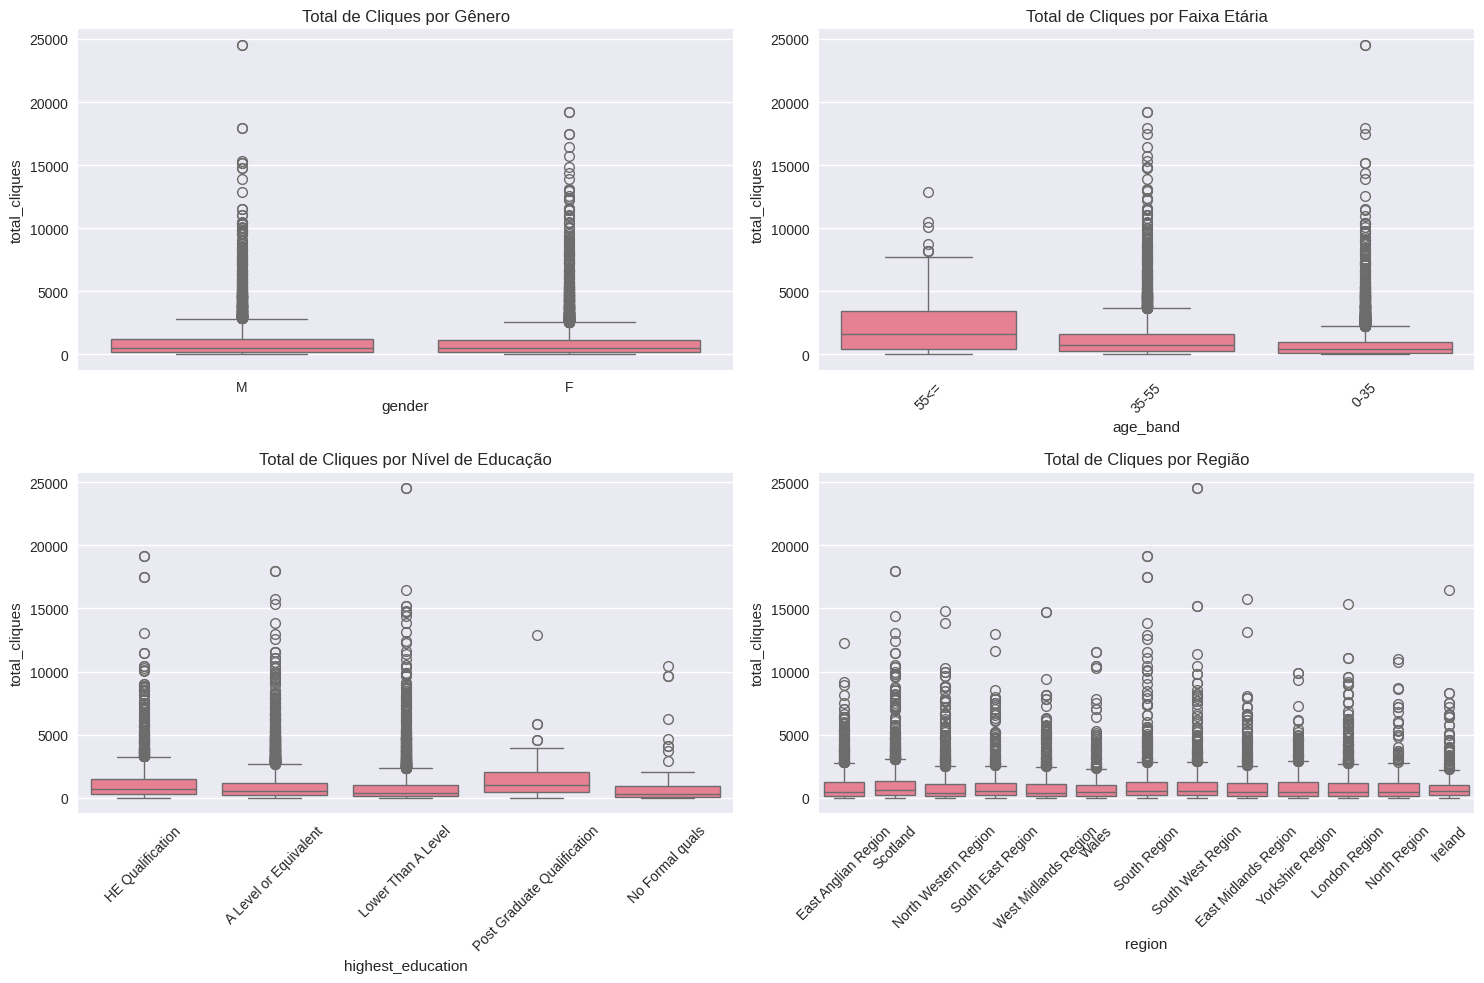

In [ ]:
# Análise demográfica vs engajamento
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Gênero vs Cliques
sns.boxplot(data=df_merged, x='gender', y='total_cliques', ax=axes[0,0])
axes[0,0].set_title('Total de Cliques por Gênero')

# Faixa Etária vs Cliques
sns.boxplot(data=df_merged, x='age_band', y='total_cliques', ax=axes[0,1])
axes[0,1].set_title('Total de Cliques por Faixa Etária')
axes[0,1].tick_params(axis='x', rotation=45)

# Educação vs Cliques
sns.boxplot(data=df_merged, x='highest_education', y='total_cliques', ax=axes[1,0])
axes[1,0].set_title('Total de Cliques por Nível de Educação')
axes[1,0].tick_params(axis='x', rotation=45)

# Região vs Cliques
sns.boxplot(data=df_merged, x='region', y='total_cliques', ax=axes[1,1])
axes[1,1].set_title('Total de Cliques por Região')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

####Análise Temporal Detalhada

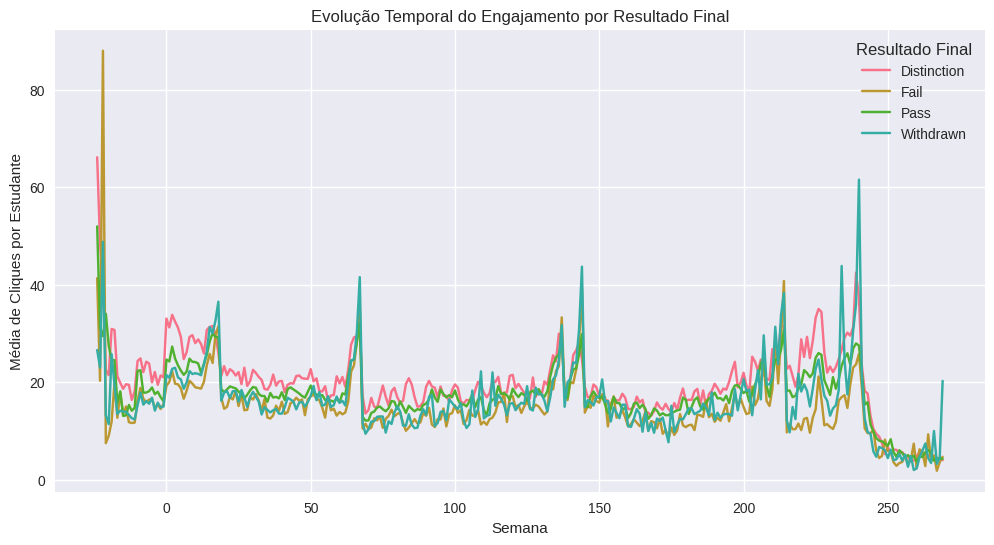

In [ ]:
# Análise temporal do engajamento por resultado final
# Agrupar cliques por estudante e semana
cliques_semana_estudante = df_cliques.groupby(['id_student', 'date'])['sum_click'].sum().reset_index()

# Juntar com resultado final
cliques_semana_estudante = pd.merge(cliques_semana_estudante, df_info[['id_student', 'final_result']], on='id_student')

# Calcular média de cliques por semana por grupo de resultado
cliques_semana_media = cliques_semana_estudante.groupby(['date', 'final_result'])['sum_click'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=cliques_semana_media, x='date', y='sum_click', hue='final_result')
plt.title('Evolução Temporal do Engajamento por Resultado Final')
plt.xlabel('Semana')
plt.ylabel('Média de Cliques por Estudante')
plt.legend(title='Resultado Final')
plt.show()

#### Estatísticas Descritivas

Estatísticas Descritivas - Cliques:
       total_cliques  media_cliques  num_interacoes
count   16012.000000   16012.000000    16012.000000
mean      959.724644       3.017976      281.262366
std      1423.115357       1.175451      338.591444
min         1.000000       1.000000        1.000000
25%       176.000000       2.274155       66.750000
50%       495.000000       2.785714      175.000000
75%      1188.000000       3.511858      367.000000
max     24538.000000      20.028933     5240.000000

Estatísticas Descritivas - Notas:
         media_nota      max_nota      min_nota  num_avaliacoes
count  25714.000000  25714.000000  25714.000000    25714.000000
mean      72.649848     87.534028     53.487750        7.691452
std       15.601527     15.980118     22.552997        4.525895
min        0.000000      0.000000      0.000000        1.000000
25%       64.559524     80.000000     40.000000        4.000000
50%       75.577381     93.000000     58.000000        7.000000
75%       84.

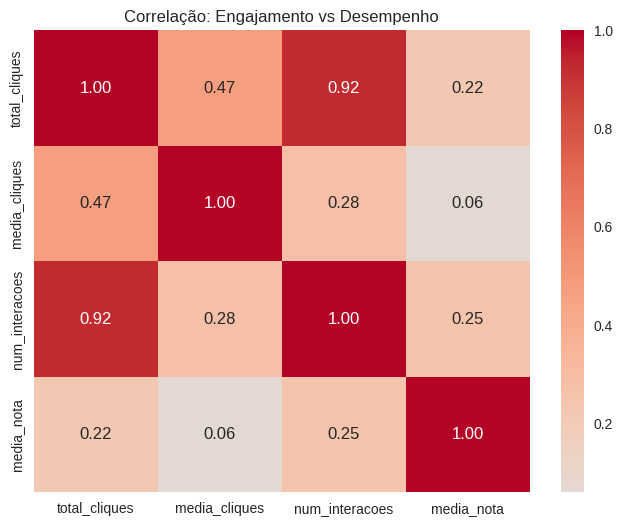

In [ ]:
# Estatísticas descritivas para variáveis numéricas
print("Estatísticas Descritivas - Cliques:")
print(df_merged[['total_cliques', 'media_cliques', 'num_interacoes']].describe())

if 'media_nota' in df_merged.columns:
    print("\nEstatísticas Descritivas - Notas:")
    print(df_merged[['media_nota', 'max_nota', 'min_nota', 'num_avaliacoes']].describe())

# Correlações entre engajamento e desempenho
if 'media_nota' in df_merged.columns:
    correlacoes = df_merged[['total_cliques', 'media_cliques', 'num_interacoes', 'media_nota']].corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(correlacoes, annot=True, cmap='coolwarm', center=0, fmt='.2f')
    plt.title('Correlação: Engajamento vs Desempenho')
    plt.show()

### ML: modelar com RandomForest para prever sucesso (Pass/Distinction) vs não-sucesso (Fail/Withdraw).

####Preparação dos Dados e Feature Engineering

In [ ]:
# Criar a variável target binária
df_info['target'] = df_info['final_result'].apply(
    lambda x: 1 if x in ['Pass', 'Distinction'] else 0  # 1 = Sucesso, 0 = Não-sucesso
)

# Agregar features de engajamento (cliques)
cliques_features = df_cliques.groupby('id_student').agg({
    'sum_click': ['sum', 'mean', 'std', 'count'],  # total, média, desvio padrão, número de interações
    'date': ['min', 'max', 'nunique']  # primeira interação, última interação, semanas únicas com interação
}).reset_index()

# Renomear colunas
cliques_features.columns = [
    'id_student',
    'total_cliques', 'media_cliques', 'std_cliques', 'num_interacoes',
    'primeira_interacao', 'ultima_interacao', 'semanas_ativas'
]

# Calcular duração do engajamento
cliques_features['duracao_engajamento'] = cliques_features['ultima_interacao'] - cliques_features['primeira_interacao']

# Agregar features de avaliações (notas)
if 'score' in df_nota.columns:
    notas_features = df_nota.groupby('id_student').agg({
        'score': ['mean', 'max', 'min', 'std', 'count'],  # estatísticas das notas
        'date_submitted': ['mean', 'std']  # tempo de submissão
    }).reset_index()

    notas_features.columns = [
        'id_student',
        'media_nota', 'max_nota', 'min_nota', 'std_nota', 'num_avaliacoes',
        'tempo_medio_submissao', 'variabilidade_submissao'
    ]
else:
    # Criar dataframe vazio se não houver notas
    notas_features = pd.DataFrame({'id_student': df_info['id_student'].unique()})

# Agregar features dos materiais VLE
if 'activity_type' in df_semana.columns:
    # Contar tipos de atividades por estudante
    atividade_cliques = pd.merge(df_cliques, df_semana[['id_site', 'activity_type']],
                                on='id_site', how='left')

    atividade_features = pd.get_dummies(atividade_cliques, columns=['activity_type'],
                                      prefix='clique').groupby('id_student').sum().reset_index()

    # Manter apenas colunas de atividade e id_student
    atividade_cols = [col for col in atividade_features.columns if 'clique_' in col] + ['id_student']
    atividade_features = atividade_features[atividade_cols]
else:
    atividade_features = pd.DataFrame({'id_student': df_info['id_student'].unique()})

/tmp/ipython-input-1119044300.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_info['target'] = df_info['final_result'].apply(


####Unir Todas as Features

In [ ]:
# Juntar todas as features com a informação base
df_final = df_info.copy()

# Juntar features de cliques
df_final = pd.merge(df_final, cliques_features, on='id_student', how='left')

# Juntar features de notas (se disponível)
df_final = pd.merge(df_final, notas_features, on='id_student', how='left')

# Juntar features de atividades (se disponível)
df_final = pd.merge(df_final, atividade_features, on='id_student', how='left')

# Preencher valores nulos resultantes dos joins
df_final = df_final.fillna(0)

print(f"Shape final do dataset: {df_final.shape}")
print(f"Colunas disponíveis: {df_final.columns.tolist()}")

Shape final do dataset: (31482, 44)
Colunas disponíveis: ['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'target', 'total_cliques', 'media_cliques', 'std_cliques', 'num_interacoes', 'primeira_interacao', 'ultima_interacao', 'semanas_ativas', 'duracao_engajamento', 'media_nota', 'max_nota', 'min_nota', 'std_nota', 'num_avaliacoes', 'tempo_medio_submissao', 'variabilidade_submissao', 'clique_dataplus', 'clique_externalquiz', 'clique_forumng', 'clique_glossary', 'clique_homepage', 'clique_oucollaborate', 'clique_oucontent', 'clique_ouelluminate', 'clique_ouwiki', 'clique_page', 'clique_questionnaire', 'clique_quiz', 'clique_resource', 'clique_sharedsubpage', 'clique_subpage', 'clique_url']


####Preparação para Modelagem

In [ ]:
# Selecionar colunas para features (excluir identificadores e colunas não úteis)
exclude_cols = ['id_student', 'final_result', 'target']  # target será nossa variável y
feature_cols = [col for col in df_final.columns if col not in exclude_cols]

# Separar variáveis categóricas e numéricas
categorical_cols = df_final[feature_cols].select_dtypes(include=['object']).columns.tolist()
numeric_cols = df_final[feature_cols].select_dtypes(include=[np.number]).columns.tolist()

print(f"Variáveis categóricas: {categorical_cols}")
print(f"Variáveis numéricas: {numeric_cols}")

# Codificar variáveis categóricas
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_final[col] = le.fit_transform(df_final[col].astype(str))
    label_encoders[col] = le

# Definir X e y
X = df_final[numeric_cols + categorical_cols]
y = df_final['target']

print(f"Shape de X: {X.shape}")
print(f"Distribuição do target: {pd.Series(y).value_counts()}")
print(f"Proporção de sucesso: {y.mean():.2%}")

Variáveis categóricas: ['code_module', 'code_presentation', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability']
Variáveis numéricas: ['num_of_prev_attempts', 'studied_credits', 'total_cliques', 'media_cliques', 'std_cliques', 'num_interacoes', 'primeira_interacao', 'ultima_interacao', 'semanas_ativas', 'duracao_engajamento', 'media_nota', 'max_nota', 'min_nota', 'std_nota', 'num_avaliacoes', 'tempo_medio_submissao', 'variabilidade_submissao', 'clique_dataplus', 'clique_externalquiz', 'clique_forumng', 'clique_glossary', 'clique_homepage', 'clique_oucollaborate', 'clique_oucontent', 'clique_ouelluminate', 'clique_ouwiki', 'clique_page', 'clique_questionnaire', 'clique_quiz', 'clique_resource', 'clique_sharedsubpage', 'clique_subpage', 'clique_url']
Shape de X: (31482, 41)
Distribuição do target: target
0    16827
1    14655
Name: count, dtype: int64
Proporção de sucesso: 46.55%


####Modelagem com RandomForest

In [ ]:
# Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Normalizar features numéricas
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

# Treinar modelo RandomForest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    class_weight='balanced'  # importante para dados desbalanceados
)

# Treinar o modelo
rf_model.fit(X_train_scaled, y_train)

# Fazer previsões
y_pred = rf_model.predict(X_test_scaled)
y_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]  # probabilidades para a classe 1

####Avaliação do Modelo

=== RELATÓRIO DE CLASSIFICAÇÃO ===
              precision    recall  f1-score   support

 Não-sucesso       0.96      0.88      0.92      5048
     Sucesso       0.88      0.96      0.92      4397

    accuracy                           0.92      9445
   macro avg       0.92      0.92      0.92      9445
weighted avg       0.92      0.92      0.92      9445


Acurácia: 0.9177


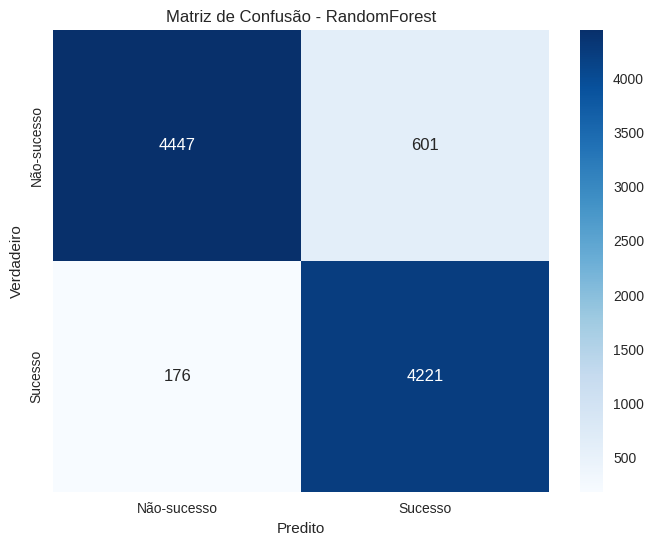


Validação Cruzada (5-fold): 0.9154 (±0.0039)


In [ ]:
# Métricas de avaliação
print("=== RELATÓRIO DE CLASSIFICAÇÃO ===")
print(classification_report(y_test, y_pred, target_names=['Não-sucesso', 'Sucesso']))

print(f"\nAcurácia: {accuracy_score(y_test, y_pred):.4f}")

# Matriz de confusão
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não-sucesso', 'Sucesso'],
            yticklabels=['Não-sucesso', 'Sucesso'])
plt.title('Matriz de Confusão - RandomForest')
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
plt.show()

# Validação cruzada
cv_scores = cross_val_score(rf_model, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"\nValidação Cruzada (5-fold): {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")

####Análise de Importância das Features

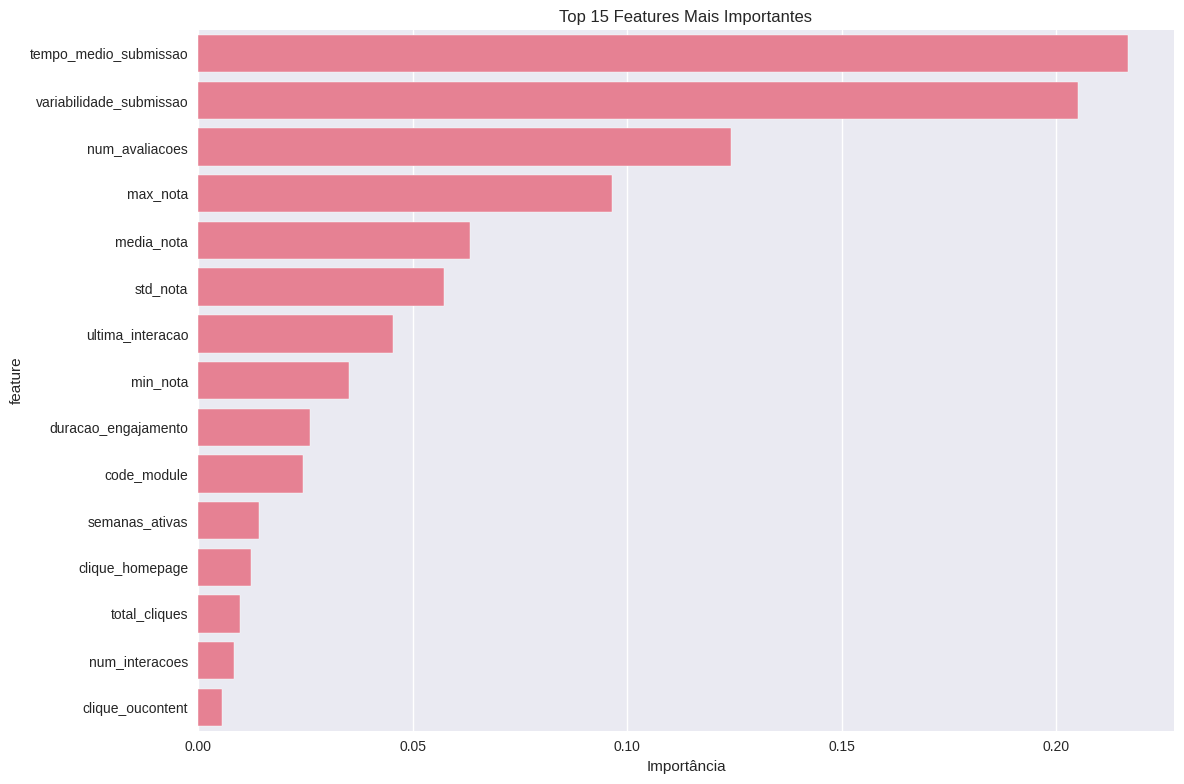

Top 10 features mais importantes:
                    feature  importance
15    tempo_medio_submissao    0.216576
16  variabilidade_submissao    0.205115
14           num_avaliacoes    0.124144
11                 max_nota    0.096459
10               media_nota    0.063424
13                 std_nota    0.057341
7          ultima_interacao    0.045441
12                 min_nota    0.035254
9       duracao_engajamento    0.026091
33              code_module    0.024550


In [ ]:
# Importância das features
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importance.head(15), x='importance', y='feature')
plt.title('Top 15 Features Mais Importantes')
plt.xlabel('Importância')
plt.tight_layout()
plt.show()

print("Top 10 features mais importantes:")
print(feature_importance.head(10))

####Análise de Probabilidades e Limiares

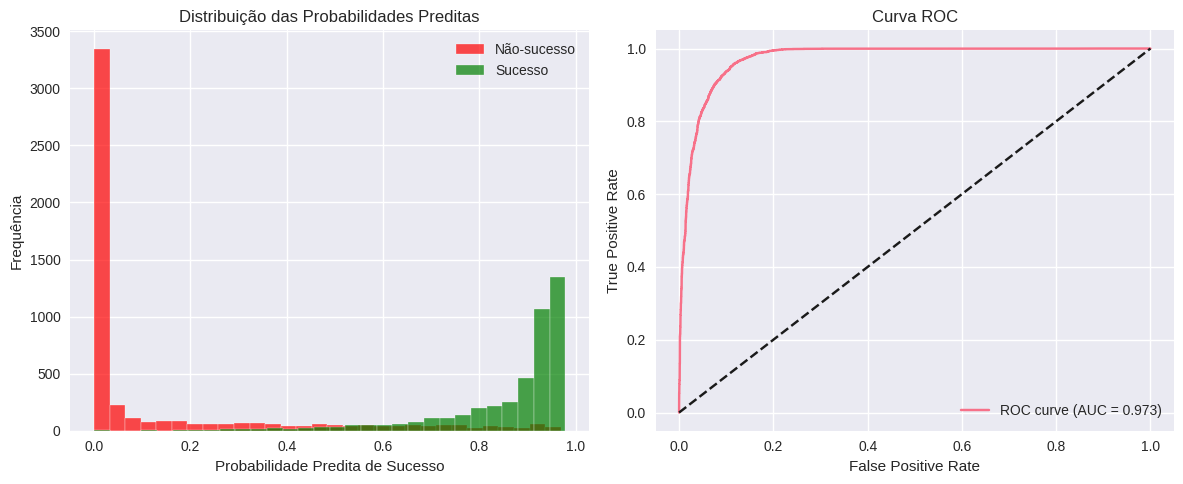

In [ ]:
# Analisar distribuição das probabilidades
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(y_pred_proba[y_test == 0], bins=30, alpha=0.7, label='Não-sucesso', color='red')
plt.hist(y_pred_proba[y_test == 1], bins=30, alpha=0.7, label='Sucesso', color='green')
plt.xlabel('Probabilidade Predita de Sucesso')
plt.ylabel('Frequência')
plt.legend()
plt.title('Distribuição das Probabilidades Preditas')

plt.subplot(1, 2, 2)
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend()

plt.tight_layout()
plt.show()

####Função para Previsão de Novos Estudantes

In [ ]:
def predict_student_success(model, scaler, student_data, feature_columns):
    """
    Prediz a probabilidade de sucesso para um novo estudante

    Args:
        model: modelo treinado
        scaler: scaler treinado
        student_data: dicionário com dados do estudante
        feature_columns: lista de colunas usadas no treino

    Returns:
        probabilidade de sucesso
    """
    # Criar dataframe com os dados do estudante
    student_df = pd.DataFrame([student_data])

    # Garantir que todas as colunas estejam presentes
    for col in feature_columns:
        if col not in student_df.columns:
            student_df[col] = 0

    # Reordenar colunas
    student_df = student_df[feature_columns]

    # Codificar variáveis categóricas (usando os encoders treinados)
    for col in categorical_cols:
        if col in student_df.columns:
            try:
                student_df[col] = label_encoders[col].transform(student_df[col].astype(str))
            except:
                # Se valor não visto durante treino, usar valor mais frequente
                student_df[col] = 0

    # Normalizar features numéricas
    student_df_scaled = student_df.copy()
    student_df_scaled[numeric_cols] = scaler.transform(student_df[numeric_cols])

    # Fazer previsão
    probability = model.predict_proba(student_df_scaled)[0, 1]

    return probability

# Exemplo de uso:
# student_example = {
#     'total_cliques': 1500,
#     'media_cliques': 25.5,
#     'num_interacoes': 60,
#     'media_nota': 75.0,
#     'gender': 'M',
#     'age_band': '35-55'
# }
# prob = predict_student_success(rf_model, scaler, student_example, X.columns.tolist())
# print(f"Probabilidade de sucesso: {prob:.2%}")

####Salvando o Modelo e Componentes

Joblib é uma biblioteca em Python amplamente utilizada na área de ciência de dados e machine learning. Ela fornece ferramentas eficientes para paralelizar e distribuir tarefas computacionais, permitindo que várias tarefas sejam executadas simultaneamente, o que é essencial para acelerar o tempo de processamento de algoritmos e melhorar a eficiência dos projetos. Além disso, o Joblib oferece recursos de armazenamento e recuperação de objetos Python em disco, facilitando o armazenamento de modelos treinados ou resultados intermediários de experimentos.

In [ ]:
# Salvar modelo e componentes
joblib.dump(rf_model, 'random_forest_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoders, 'label_encoders.pkl')
joblib.dump(X.columns.tolist(), 'feature_columns.pkl')

print("Modelo e componentes salvos com sucesso!")

Modelo e componentes salvos com sucesso!


###NumPy (Tensor): representar aluno × semana × cliques e extrair estatísticas.

####Análise Preliminar e Preparação

In [ ]:
print("=== ANÁLISE PRELIMINAR ===")
print(f"Tamanho do df_cliques: {df_cliques.shape}")
print(f"Memória usada: {df_cliques.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Verificar se precisamos amostrar os dados
if len(df_cliques) > 1000000:
    print("Dataset muito grande, vamos amostrar 50% para análise")
    df_cliques_sample = df_cliques.sample(frac=0.5, random_state=42)
else:
    df_cliques_sample = df_cliques.copy()

alunos_unicos = sorted(df_cliques_sample['id_student'].unique())
semanas_unicas = sorted(df_cliques_sample['date'].unique())

print(f"Número de alunos: {len(alunos_unicos)}")
print(f"Número de semanas: {len(semanas_unicas)}")
print(f"Tamanho potencial do tensor: {len(alunos_unicos)} x {len(semanas_unicas)} = {len(alunos_unicos)*len(semanas_unicas):,} elementos")

=== ANÁLISE PRELIMINAR ===
Tamanho do df_cliques: (3818285, 6)
Memória usada: 502.51 MB
Dataset muito grande, vamos amostrar 50% para análise
Número de alunos: 13494
Número de semanas: 295
Tamanho potencial do tensor: 13494 x 295 = 3,980,730 elementos


####Matriz Esparsa

In [ ]:
print("\n=== CRIANDO MATRIZ ESPARSA ===")
from scipy.sparse import lil_matrix

# Usar matriz esparsa para economizar memória
matriz_cliques = lil_matrix((len(alunos_unicos), len(semanas_unicas)), dtype=np.float32)

# Mapeamentos
aluno_para_indice = {aluno: idx for idx, aluno in enumerate(alunos_unicos)}
semana_para_indice = {semana: idx for idx, semana in enumerate(semanas_unicas)}

print("Preenchendo matriz esparsa...")
for _, row in df_cliques_sample.iterrows():
    try:
        aluno_idx = aluno_para_indice[row['id_student']]
        semana_idx = semana_para_indice[row['date']]
        matriz_cliques[aluno_idx, semana_idx] += row['sum_click']
    except KeyError:
        continue

print("Matriz esparsa criada com sucesso!")
print(f"Shape da matriz: {matriz_cliques.shape}")
print(f"Elementos não-zero: {matriz_cliques.nnz}")


=== CRIANDO MATRIZ ESPARSA ===
Preenchendo matriz esparsa...
Matriz esparsa criada com sucesso!
Shape da matriz: (13494, 295)
Elementos não-zero: 601303


####Estatísticas Básicas

In [ ]:
print("\n=== ESTATÍSTICAS BÁSICAS ===")

# Converter para array denso apenas para as estatísticas (se possível)
if matriz_cliques.nnz < 1000000:  # Limite seguro
    matriz_densa = matriz_cliques.toarray()

    # Estatísticas por aluno
    cliques_por_aluno = matriz_densa.sum(axis=1)
    print(f"Média de cliques por aluno: {cliques_por_aluno.mean():.2f}")
    print(f"Aluno mais ativo: {cliques_por_aluno.max():.0f} cliques")
    print(f"Aluno menos ativo: {cliques_por_aluno.min():.0f} cliques")

    # Estatísticas por semana
    cliques_por_semana = matriz_densa.sum(axis=0)
    print(f"Média de cliques por semana: {cliques_por_semana.mean():.2f}")
    print(f"Semana mais movimentada: {cliques_por_semana.max():.0f} cliques")

else:
    # Calcular estatísticas de forma eficiente
    cliques_por_aluno = np.array(matriz_cliques.sum(axis=1)).flatten()
    cliques_por_semana = np.array(matriz_cliques.sum(axis=0)).flatten()

    print(f"Média de cliques por aluno: {cliques_por_aluno.mean():.2f}")
    print(f"Média de cliques por semana: {cliques_por_semana.mean():.2f}")


=== ESTATÍSTICAS BÁSICAS ===
Média de cliques por aluno: 479.80
Aluno mais ativo: 12459 cliques
Aluno menos ativo: 0 cliques
Média de cliques por semana: 21947.20
Semana mais movimentada: 90618 cliques


####Análise por Grupos

In [ ]:
print("\n=== ANÁLISE POR GRUPOS ===")

# Analisar por quintis de engajamento
quintis = np.percentile(cliques_por_aluno, [0, 20, 40, 60, 80, 100])
print("Quintis de engajamento:")
for i in range(len(quintis)-1):
    count = np.sum((cliques_por_aluno >= quintis[i]) & (cliques_por_aluno < quintis[i+1]))
    print(f"Quintil {i+1}: {quintis[i]:.0f} - {quintis[i+1]:.0f} cliques ({count} alunos)")

# Padrão temporal médio
if matriz_cliques.nnz < 500000:
    padrao_temporal = matriz_densa.mean(axis=0)
else:
    # Calcular média temporal de forma eficiente
    padrao_temporal = np.array(matriz_cliques.mean(axis=0)).flatten()

print("\nEvolução temporal do engajamento:")
for semana, engajamento in enumerate(padrao_temporal[:10]):  # Mostrar apenas 10 semanas
    print(f"Semana {semanas_unicas[semana]}: {engajamento:.2f} cliques")


=== ANÁLISE POR GRUPOS ===
Quintis de engajamento:
Quintil 1: 0 - 67 cliques (2674 alunos)
Quintil 2: 67 - 173 cliques (2713 alunos)
Quintil 3: 173 - 352 cliques (2706 alunos)
Quintil 4: 352 - 713 cliques (2702 alunos)
Quintil 5: 713 - 12459 cliques (2698 alunos)

Evolução temporal do engajamento:
Semana -24.0: 0.31 cliques
Semana -23.0: 0.14 cliques
Semana -22.0: 0.14 cliques
Semana -21.0: 0.06 cliques
Semana -20.0: 0.08 cliques
Semana -19.0: 0.11 cliques
Semana -18.0: 2.02 cliques
Semana -17.0: 0.93 cliques
Semana -16.0: 1.10 cliques
Semana -15.0: 0.73 cliques


####Visualizações Eficientes


=== VISUALIZAÇÕES ===


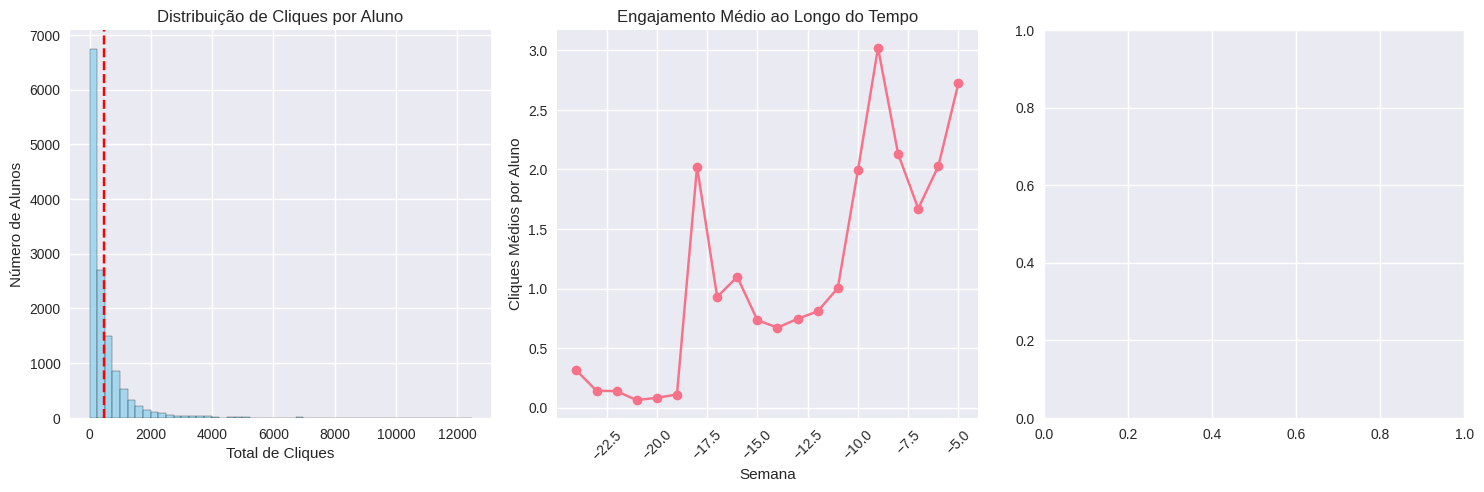

In [ ]:
print("\n=== VISUALIZAÇÕES ===")

plt.figure(figsize=(15, 5))

# Distribuição de cliques por aluno
plt.subplot(1, 3, 1)
plt.hist(cliques_por_aluno, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Distribuição de Cliques por Aluno')
plt.xlabel('Total de Cliques')
plt.ylabel('Número de Alunos')
plt.axvline(np.mean(cliques_por_aluno), color='red', linestyle='--', label=f'Média: {np.mean(cliques_por_aluno):.1f}')

# Engajamento ao longo do tempo
plt.subplot(1, 3, 2)
semanas_plot = semanas_unicas[:min(20, len(semanas_unicas))]  # Limitar a 20 semanas
engajamento_plot = padrao_temporal[:len(semanas_plot)]
plt.plot(semanas_plot, engajamento_plot, marker='o', linestyle='-')
plt.title('Engajamento Médio ao Longo do Tempo')
plt.xlabel('Semana')
plt.ylabel('Cliques Médios por Aluno')
plt.xticks(rotation=45)

# Heatmap de amostra (apenas 100 alunos x 20 semanas)
plt.subplot(1, 3, 3)
if matriz_cliques.nnz < 100000:
    sample_matrix = matriz_densa[:100, :20]  # Amostra pequena
    sns.heatmap(sample_matrix, cmap='YlOrRd', cbar_kws={'label': 'Cliques'})
    plt.title('Heatmap: Cliques por Aluno × Semana\n(Amostra de 100 alunos, 20 semanas)')
    plt.xlabel('Semana')
    plt.ylabel('Aluno')

plt.tight_layout()
plt.show()

####Análise de Consistência

In [ ]:
print("\n=== ANÁLISE DE CONSISTÊNCIA ===")

# Calcular consistência do engajamento (apenas se matriz for manejável)
if matriz_cliques.nnz < 500000:
    # Coeficiente de variação por aluno
    mean_by_aluno = matriz_densa.mean(axis=1)
    std_by_aluno = matriz_densa.std(axis=1)
    cv_by_aluno = np.where(mean_by_aluno > 0, std_by_aluno / mean_by_aluno, 0)

    print(f"Alunos com engajamento consistente (CV < 0.5): {np.sum(cv_by_aluno < 0.5)}")
    print(f"Alunos com engajamento variável (CV >= 0.5): {np.sum(cv_by_aluno >= 0.5)}")

    # Taxa de retenção por semana
    alunos_ativos_por_semana = (matriz_densa > 0).sum(axis=0)
    taxa_retencao = alunos_ativos_por_semana / len(alunos_unicos)

    print("\nTaxa de retenção nas primeiras 10 semanas:")
    for i in range(min(10, len(taxa_retencao))):
        print(f"Semana {semanas_unicas[i]}: {taxa_retencao[i]:.1%}")


=== ANÁLISE DE CONSISTÊNCIA ===


####Salvar Resultados

In [ ]:
print("\n=== SALVANDO RESULTADOS ===")

# Salvar estatísticas resumidas
estatisticas_resumo = pd.DataFrame({
    'aluno_id': alunos_unicos,
    'total_cliques': cliques_por_aluno,
    'semanas_ativas': np.array((matriz_cliques > 0).sum(axis=1)).flatten()
})

# Adicionar mais estatísticas se possível
if matriz_cliques.nnz < 500000:
    estatisticas_resumo['media_cliques'] = mean_by_aluno
    estatisticas_resumo['std_cliques'] = std_by_aluno
    estatisticas_resumo['cv_engajamento'] = cv_by_aluno

estatisticas_resumo.to_csv('estatisticas_engajamento.csv', index=False)
print("Estatísticas salvas com sucesso!")

print(f"\n=== RESUMO ===")
print(f"Alunos analisados: {len(alunos_unicos)}")
print(f"Semanas analisadas: {len(semanas_unicas)}")
print(f"Total de interações: {matriz_cliques.nnz}")
print(f"Cliques totais: {matriz_cliques.sum():.0f}")


=== SALVANDO RESULTADOS ===
Estatísticas salvas com sucesso!

=== RESUMO ===
Alunos analisados: 13494
Semanas analisadas: 295
Total de interações: 601303
Cliques totais: 6474423


##Gold


####Gold: criar bases analíticas (agregações e features finais)

In [ ]:
print("=== CRIAÇÃO DE BASES ANALÍTICAS (GOLD) ===")

# 1.1 Features básicas de engajamento
def criar_features_engajamento_basico(df_cliques):
    """Cria features básicas de engajamento por aluno"""
    features_engajamento = df_cliques.groupby('id_student').agg({
        'sum_click': ['sum', 'mean', 'std', 'count'],  # Estatísticas básicas
        'date': ['min', 'max', 'nunique']  # Primeira, última e semanas únicas
    }).reset_index()

    # Renomear colunas
    features_engajamento.columns = [
        'id_student',
        'total_cliques', 'media_cliques', 'std_cliques', 'num_interacoes',
        'primeira_semana', 'ultima_semana', 'semanas_ativas'
    ]

    # Calcular duração do engajamento
    features_engajamento['duracao_engajamento'] = (
        features_engajamento['ultima_semana'] - features_engajamento['primeira_semana']
    )

    return features_engajamento

# 1.2 Features básicas de desempenho (se disponível)
def criar_features_desempenho_basico(df_nota):
    """Cria features básicas de desempenho por aluno"""
    if 'score' not in df_nota.columns:
        return pd.DataFrame()

    features_desempenho = df_nota.groupby('id_student').agg({
        'score': ['mean', 'max', 'min', 'count'],  # Estatísticas de notas
        'date_submitted': ['mean', 'std']  # Tempo de submissão
    }).reset_index()

    features_desempenho.columns = [
        'id_student',
        'media_nota', 'max_nota', 'min_nota', 'num_avaliacoes',
        'tempo_medio_submissao', 'variabilidade_submissao'
    ]

    return features_desempenho

=== CRIAÇÃO DE BASES ANALÍTICAS (GOLD) ===


In [ ]:
# Interação + Funções: perguntar ao usuário filtros/limiares e aplicar via funções.


In [ ]:
# =============================================
# INTERMEDIÁRIO: Funções Avançadas de Análise
# =============================================

def analisar_engajamento_por_grupo(df, coluna_grupo, metrica='total_cliques'):
    """Analisa engajamento por grupo demográfico"""
    if coluna_grupo not in df.columns:
        print(f"⚠️ Coluna '{coluna_grupo}' não encontrada")
        return None

    analise = df.groupby(coluna_grupo).agg({
        metrica: ['mean', 'std', 'count'],
        'target_sucesso': 'mean'
    }).round(2)

    analise.columns = [f'{metrica}_media', f'{metrica}_std', 'contagem', 'taxa_sucesso']

    return analise.sort_values('taxa_sucesso', ascending=False)

def identificar_padroes_risco(df, limiar_engajamento=100, limiar_consistencia=0.7):
    """Identifica alunos em risco baseado em múltiplos critérios"""

    criterios_risco = (
        (df['total_cliques'] < limiar_engajamento) |  # Baixo engajamento
        (df['coef_variacao_engajamento'] > limiar_consistencia) |  # Engajamento inconsistente
        (df['semanas_ativas'] < df['semanas_ativas'].median())  # Poucas semanas ativas
    )

    alunos_risco = df[criterios_risco].copy()
    alunos_risco['score_risco'] = (
        (df['total_cliques'] < limiar_engajamento).astype(int) +
        (df['coef_variacao_engajamento'] > limiar_consistencia).astype(int) +
        (df['semanas_ativas'] < df['semanas_ativas'].median()).astype(int)
    )

    return alunos_risco.sort_values('score_risco', ascending=False)


In [ ]:
# =============================================
# SISTEMA INTERATIVO DE CONSULTA
# =============================================

def sistema_interativo_consultas(base_gold):
    """Sistema interativo para consultas na base gold"""

    print("\n" + "="*50)
    print("SISTEMA INTERATIVO DE CONSULTAS")
    print("="*50)

    while True:
        print("\nOpções disponíveis:")
        print("1. Filtrar por engajamento mínimo")
        print("2. Filtrar por média de notas")
        print("3. Filtrar por semanas ativas")
        print("4. Analisar engajamento por grupo")
        print("5. Identificar alunos em risco")
        print("6. Estatísticas descritivas")
        print("7. Sair")

        opcao = input("\nEscolha uma opção (1-7): ").strip()

        if opcao == '1':
            try:
                limiar = int(input("Digite o número mínimo de cliques: "))
                resultado = filtrar_por_engajamento_minimo(base_gold, limiar)
                print(f"✅ Encontrados {len(resultado)} alunos com pelo menos {limiar} cliques")
                print(f"Taxa de sucesso: {resultado['target_sucesso'].mean():.1%}")
            except ValueError:
                print("❌ Por favor, digite um número válido")

        elif opcao == '2':
            if 'media_nota' in base_gold.columns:
                try:
                    limiar = float(input("Digite a nota mínima: "))
                    resultado = filtrar_por_media_nota(base_gold, limiar)
                    print(f"✅ Encontrados {len(resultado)} alunos com nota média ≥ {limiar}")
                    print(f"Taxa de sucesso: {resultado['target_sucesso'].mean():.1%}")
                except ValueError:
                    print("❌ Por favor, digite um número válido")
            else:
                print("❌ Dados de notas não disponíveis")

        elif opcao == '3':
            try:
                limiar = int(input("Digite o número mínimo de semanas ativas: "))
                resultado = filtrar_por_semanas_ativas(base_gold, limiar)
                print(f"✅ Encontrados {len(resultado)} alunos ativos em pelo menos {limiar} semanas")
                print(f"Taxa de sucesso: {resultado['target_sucesso'].mean():.1%}")
            except ValueError:
                print("❌ Por favor, digite um número válido")

        elif opcao == '4':
            print("Colunas disponíveis para agrupamento:")
            colunas_grupo = ['gender', 'region', 'highest_education', 'age_band', 'disability']
            for i, col in enumerate(colunas_grupo, 1):
                if col in base_gold.columns:
                    print(f"{i}. {col}")

            try:
                escolha = int(input("Escolha o número da coluna: ")) - 1
                if 0 <= escolha < len(colunas_grupo):
                    coluna = colunas_grupo[escolha]
                    resultado = analisar_engajamento_por_grupo(base_gold, coluna)
                    if resultado is not None:
                        print(f"\nAnálise por {coluna}:")
                        print(resultado)
                else:
                    print("❌ Opção inválida")
            except ValueError:
                print("❌ Por favor, digite um número válido")

        elif opcao == '5':
            try:
                engajamento = int(input("Limiar de engajamento (cliques totais) [100]: ") or "100")
                consistencia = float(input("Limiar de inconsistência (0-1) [0.7]: ") or "0.7")

                resultado = identificar_padroes_risco(base_gold, engajamento, consistencia)
                print(f"✅ Identificados {len(resultado)} alunos em risco")
                print(f"Top 5 alunos com maior score de risco:")
                print(resultado[['id_student', 'total_cliques', 'coef_variacao_engajamento', 'score_risco']].head())

            except ValueError:
                print("❌ Por favor, digite valores numéricos válidos")

        elif opcao == '6':
            print("\n📊 ESTATÍSTICAS DESCRITIVAS DA BASE:")
            print(f"Total de alunos: {len(base_gold)}")
            print(f"Taxa geral de sucesso: {base_gold['target_sucesso'].mean():.1%}")

            if 'total_cliques' in base_gold.columns:
                print(f"Média de cliques: {base_gold['total_cliques'].mean():.0f}")
                print(f"Média de semanas ativas: {base_gold['semanas_ativas'].mean():.1f}")

        elif opcao == '7':
            print("👋 Saindo do sistema...")
            break

        else:
            print("❌ Opção inválida. Tente novamente.")

        # Perguntar se quer continuar
        if opcao in ['1', '2', '3', '4', '5']:
            continuar = input("\nDeseja fazer outra consulta? (s/n): ").strip().lower()
            if continuar != 's':
                print("👋 Saindo do sistema...")
                break

# =============================================
# EXECUTAR O SISTEMA INTERATIVO
# =============================================

# Executar sistema interativo
sistema_interativo_consultas(base_gold)

NameError: name 'base_gold' is not defined

In [ ]:
# =============================================
# FUNÇÕES ADICIONAIS ÚTEIS
# =============================================

def exportar_relatorio_personalizado(df, filtros=None, colunas=None):
    """Exporta um relatório personalizado baseado em filtros"""

    if filtros:
        df_filtrado = df.copy()
        for coluna, valor in filtros.items():
            if coluna in df_filtrado.columns:
                df_filtrado = df_filtrado[df_filtrado[coluna] >= valor]
    else:
        df_filtrado = df

    if colunas:
        df_filtrado = df_filtrado[colunas]

    nome_arquivo = f"relatorio_personalizado_{pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')}.csv"
    df_filtrado.to_csv(nome_arquivo, index=False)

    print(f"✅ Relatório exportado como '{nome_arquivo}'")
    print(f"Registros exportados: {len(df_filtrado)}")

    return df_filtrado

# Exemplo de uso:
# exportar_relatorio_personalizado(
#     base_gold,
#     filtros={'total_cliques': 200, 'media_nota': 60},
#     colunas=['id_student', 'gender', 'total_cliques', 'media_nota', 'target_sucesso']
# )

def dashboard_resumo(base_gold):
    """Cria um dashboard resumo da base gold"""

    print("\n" + "="*50)
    print("DASHBOARD RESUMO - BASE GOLD")
    print("="*50)

    # Métricas principais
    print(f"📈 Total de alunos: {len(base_gold):,}")
    print(f"🎯 Taxa de sucesso: {base_gold['target_sucesso'].mean():.1%}")

    if 'total_cliques' in base_gold.columns:
        print(f"🖱️  Média de cliques: {base_gold['total_cliques'].mean():.0f}")
        print(f"📅 Média de semanas ativas: {base_gold['semanas_ativas'].mean():.1f}")

    # Distribuição por grupos
    if 'gender' in base_gold.columns:
        print(f"\n👥 Distribuição por gênero:")
        print(base_gold['gender'].value_counts())

    # Correlações (se numéricas)
    colunas_numericas = base_gold.select_dtypes(include=[np.number]).columns
    if len(colunas_numericas) > 1:
        correlacao_sucesso = base_gold[colunas_numericas].corr()['target_sucesso'].sort_values(ascending=False)
        print(f"\n🔗 Top 5 correlações com sucesso:")
        for feature, corr in correlacao_sucesso[1:6].items():  # Pular a própria target
            print(f"   {feature}: {corr:.3f}")

# Executar dashboard
dashboard_resumo(base_gold)